# Visualizations of loss Function

In [3]:
import sys
import os
main_dir = os.path.dirname(os.getcwd())
sys.path.append(main_dir)

import argparse
import os
import time

import numpy as np

from MambaCD.changedetection.configs.config import get_config

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from MambaCD.changedetection.datasets.make_data_loader import SemanticChangeDetectionDatset, make_data_loader
from MambaCD.changedetection.utils_func.metrics import Evaluator
from MambaCD.changedetection.models.STMambaSCD import STMambaSCD
import MambaCD.changedetection.utils_func.lovasz_loss as L
from torch.optim.lr_scheduler import StepLR
from MambaCD.changedetection.utils_func.mcd_utils import accuracy, SCDD_eval_all, AverageMeter

from ChangeDetection.loss import ce2_dice1, ce2_dice1_multiclass
import matplotlib.pyplot as plt

/home/e19063/ChangeDetection-Buddhi/MambaCD/classification/models/vmamba.py:252: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/home/e19063/ChangeDetection-Buddhi/MambaCD/classification/models/vmamba.py:260: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/home/e19063/ChangeDetection-Buddhi/MambaCD/classification/models/vmamba.py:275: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/home/e19063/ChangeDetection-Buddhi/MambaCD/classification/models/vmamba.py:283: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/hom

In [4]:
configs_path = os.path.join(main_dir, 'MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml')
model_path = os.path.join(main_dir, 'MambaCD/saved_models')

SECOND_DATASET_PATH = os.path.join(main_dir, 'Datasets', 'SECOND')
SECOND_TRAIN_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'train')
SECOND_TEST_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'test')
SECOND_TRAIN_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'train.txt')
SECOND_TEST_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'test.txt')

train_data_list = []
with open(SECOND_TRAIN_DATA_LIST_PATH, 'r') as f:
    for line in f:
        train_data_list.append(line.strip())

test_data_list = []
with open(SECOND_TEST_DATA_LIST_PATH, 'r') as f:
    for line in f:
        test_data_list.append(line.strip())

class ARGS:
    def __init__(self):
        self.cfg = configs_path
        self.opts = None
        self.pretrained_weight_path = None
        self.dataset = 'SECOND'
        self.type = 'train'
        self.train_dataset_path = SECOND_TRAIN_DATASET_PATH
        self.train_data_list_path = SECOND_TRAIN_DATA_LIST_PATH
        self.test_dataset_path = SECOND_TEST_DATASET_PATH
        self.test_data_list_path = SECOND_TEST_DATA_LIST_PATH
        self.shuffle = True
        self.batch_size = 1
        self.crop_size = 128
        self.train_data_name_list = train_data_list
        self.test_data_name_list = test_data_list
        self.start_iter = 0
        self.cuda = False
        self.max_iters = 400000
        self.model_type = 'MambaSCD'
        self.model_param_path = model_path
        self.resume = None
        self.learning_rate = 1e-4
        self.momentum = 0.9
        self.weight_decay = 5e-4

args = ARGS()

In [30]:
class Trainer(object):
    def __init__(self, args):
        self.args = args
        config = get_config(args)

        self.train_data_loader = make_data_loader(args)

        self.deep_model = STMambaSCD(
            output_cd = 2, 
            output_clf = 7,
            pretrained=args.pretrained_weight_path,
            patch_size=config.MODEL.VSSM.PATCH_SIZE, 
            in_chans=config.MODEL.VSSM.IN_CHANS, 
            num_classes=config.MODEL.NUM_CLASSES, 
            depths=config.MODEL.VSSM.DEPTHS, 
            dims=config.MODEL.VSSM.EMBED_DIM, 
            # ===================
            ssm_d_state=config.MODEL.VSSM.SSM_D_STATE,
            ssm_ratio=config.MODEL.VSSM.SSM_RATIO,
            ssm_rank_ratio=config.MODEL.VSSM.SSM_RANK_RATIO,
            ssm_dt_rank=("auto" if config.MODEL.VSSM.SSM_DT_RANK == "auto" else int(config.MODEL.VSSM.SSM_DT_RANK)),
            ssm_act_layer=config.MODEL.VSSM.SSM_ACT_LAYER,
            ssm_conv=config.MODEL.VSSM.SSM_CONV,
            ssm_conv_bias=config.MODEL.VSSM.SSM_CONV_BIAS,
            ssm_drop_rate=config.MODEL.VSSM.SSM_DROP_RATE,
            ssm_init=config.MODEL.VSSM.SSM_INIT,
            forward_type=config.MODEL.VSSM.SSM_FORWARDTYPE,
            # ===================
            mlp_ratio=config.MODEL.VSSM.MLP_RATIO,
            mlp_act_layer=config.MODEL.VSSM.MLP_ACT_LAYER,
            mlp_drop_rate=config.MODEL.VSSM.MLP_DROP_RATE,
            # ===================
            drop_path_rate=config.MODEL.DROP_PATH_RATE,
            patch_norm=config.MODEL.VSSM.PATCH_NORM,
            norm_layer=config.MODEL.VSSM.NORM_LAYER,
            downsample_version=config.MODEL.VSSM.DOWNSAMPLE,
            patchembed_version=config.MODEL.VSSM.PATCHEMBED,
            gmlp=config.MODEL.VSSM.GMLP,
            use_checkpoint=config.TRAIN.USE_CHECKPOINT,
            ) 
        self.deep_model = self.deep_model.cuda()
        self.model_save_path = os.path.join(args.model_param_path, args.dataset,
                                            args.model_type + '_' + str(time.time()))
        self.lr = args.learning_rate
        self.epoch = args.max_iters // args.batch_size

        if not os.path.exists(self.model_save_path):
            os.makedirs(self.model_save_path)

        if args.resume is not None:
            if not os.path.isfile(args.resume):
                raise RuntimeError("=> no checkpoint found at '{}'".format(args.resume))
            checkpoint = torch.load(args.resume)
            model_dict = {}
            state_dict = self.deep_model.state_dict()
            for k, v in checkpoint.items():
                if k in state_dict:
                    model_dict[k] = v
            state_dict.update(model_dict)
            self.deep_model.load_state_dict(state_dict)

        self.optim = optim.AdamW(self.deep_model.parameters(),
                                 lr=args.learning_rate,
                                 weight_decay=args.weight_decay)

        self.scheduler = StepLR(self.optim, step_size=10000, gamma=0.5)

    def training(self):
        best_kc = 0.0
        best_round = []
        elem_num = len(self.train_data_loader)
        train_enumerator = enumerate(self.train_data_loader)
        for _ in tqdm(range(elem_num)):
            itera, data = train_enumerator.__next__()
            pre_change_imgs, post_change_imgs, label_cd, label_clf_t1, label_clf_t2, _ = data
            print(pre_change_imgs[0].shape)

            pre_change_imgs = pre_change_imgs.cuda()
            post_change_imgs = post_change_imgs.cuda()
            label_cd = label_cd.cuda().long()
            label_clf_t1 = label_clf_t1.cuda().long()
            label_clf_t2 = label_clf_t2.cuda().long()

            print(f'labels_cd: {label_cd}')
            print(f'labels_clf_t1: {label_clf_t1}')
            print(f'labels_clf_t2: {label_clf_t2}')

            label_clf_t1[label_clf_t1 == 0] = 255
            label_clf_t2[label_clf_t2 == 0] = 255

            output_1, output_semantic_t1, output_semantic_t2 = self.deep_model(pre_change_imgs, post_change_imgs)

            # plot the input data and labels
            fig, axes = plt.subplots(2, 6, figsize=(30, 10))
            axes[0, 0].imshow(pre_change_imgs[0].permute(1, 2, 0).cpu().numpy())
            axes[0, 0].set_title('Pre Change Image')
            axes[0, 1].imshow(post_change_imgs[0].permute(1, 2, 0).cpu().numpy())
            axes[0, 1].set_title('Post Change Image')
            axes[0, 2].imshow(label_cd[0].cpu().numpy(), cmap='gray')
            axes[0, 2].set_title('Label Change Detection')
            axes[0, 3].imshow(label_clf_t1[0].cpu().numpy(), cmap='gray')
            axes[0, 3].set_title('Label Classification T1')
            axes[0, 4].imshow(label_clf_t2[0].cpu().numpy(), cmap='gray')
            axes[0, 4].set_title('Label Classification T2')

            # plot the heatmaps for all output channels
            output_1 = torch.softmax(output_1, dim=1)
            for i in range(2):
                heatmap = output_1[0, i].detach().cpu().numpy()
                axes[1, i].imshow(heatmap, cmap='hot', interpolation='nearest')
                axes[1, i].set_title(f'Change Detection Channel {i+1}')
            
            for i in range(8):
                heatmap = output_semantic_t1[0, i].detach().cpu().numpy()
                axes[1, i % 6 + 2].imshow(heatmap, cmap='viridis', interpolation='nearest')
                axes[1, i % 6 + 2].set_title(f'Semantic T1 Channel {i+1}')
                if i == 5:
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            plt.show()

            change_mask = torch.argmax(output_1, axis=1)

            # Create a mask where change_mask is 255
            mask_255 = (change_mask == 255).unsqueeze(1).expand_as(output_semantic_t1)

            output_semantic_t1[mask_255] = 0
            output_semantic_t1[:, 0, :, :][mask_255[:, 0, :, :]] = 1

            output_semantic_t2[mask_255] = 0
            output_semantic_t2[:, 0, :, :][mask_255[:, 0, :, :]] = 1

            break
            
    def validation(self):
        print('---------starting evaluation-----------')
        dataset = SemanticChangeDetectionDatset(self.args.test_dataset_path, self.args.test_data_name_list, 256, None, 'test')
        val_data_loader = DataLoader(dataset, batch_size=1, num_workers=4, drop_last=False)
        torch.cuda.empty_cache()
        acc_meter = AverageMeter()

        preds_all = []
        labels_all = []
        with torch.no_grad():
            for itera, data in enumerate(val_data_loader):
                pre_change_imgs, post_change_imgs, labels_cd, labels_clf_t1, labels_clf_t2, _ = data

                pre_change_imgs = pre_change_imgs.cuda()
                post_change_imgs = post_change_imgs.cuda()
                labels_cd = labels_cd.cuda().long()
                labels_clf_t1 = labels_clf_t1.cuda().long()
                labels_clf_t2 = labels_clf_t2.cuda().long()


                # input_data = torch.cat([pre_change_imgs, post_change_imgs], dim=1)
                output_1, output_semantic_t1, output_semantic_t2 = self.deep_model(pre_change_imgs, post_change_imgs)

                change_mask = torch.argmax(output_1, axis=1)

                # Create a mask where change_mask is 255
                mask_255 = (change_mask == 255).unsqueeze(1).expand_as(output_semantic_t1)

                output_semantic_t1[mask_255] = 0
                output_semantic_t1[:, 0, :, :][mask_255[:, 0, :, :]] = 1

                output_semantic_t2[mask_255] = 0
                output_semantic_t2[:, 0, :, :][mask_255[:, 0, :, :]] = 1

                labels_cd = labels_cd.cpu().numpy()
                labels_A = labels_clf_t1.cpu().numpy()
                labels_B = labels_clf_t2.cpu().numpy()

                change_mask = torch.argmax(output_1, axis=1).cpu().numpy()

                preds_A = torch.argmax(output_semantic_t1, dim=1).cpu().numpy()
                preds_B = torch.argmax(output_semantic_t2, dim=1).cpu().numpy()
                

                preds_scd = (preds_A - 1) * 6 + preds_B
                preds_scd[change_mask == 0] = 0

                labels_scd = (labels_A - 1) * 6 + labels_B
                labels_scd[labels_cd == 0] = 0

                for (pred_scd, label_scd) in zip(preds_scd, labels_scd):
                    acc_A, valid_sum_A = accuracy(pred_scd, label_scd)
                    preds_all.append(pred_scd)
                    labels_all.append(label_scd)
                    acc = acc_A
                    acc_meter.update(acc)

        kappa_n0, Fscd, IoU_mean, Sek = SCDD_eval_all(preds_all, labels_all, 37)
        print(f'Kappa coefficient rate is {kappa_n0}, F1 is {Fscd}, OA is {acc_meter.avg}, '
              f'mIoU is {IoU_mean}, SeK is {Sek}')
        
        return kappa_n0, Fscd, IoU_mean, Sek, acc_meter.avg

=> merge config from /home/e19063/ChangeDetection-Buddhi/MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml
False


  0%|          | 0/400000 [00:00<?, ?it/s]

torch.Size([3, 128, 128])
labels_cd: tensor([[[0, 0, 0,  ..., 1, 1, 1],
         [0, 0, 0,  ..., 1, 1, 1],
         [0, 0, 0,  ..., 1, 1, 1],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0')
labels_clf_t1: tensor([[[0, 0, 0,  ..., 5, 5, 5],
         [0, 0, 0,  ..., 5, 5, 5],
         [0, 0, 0,  ..., 5, 5, 5],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0')
labels_clf_t2: tensor([[[0, 0, 0,  ..., 3, 3, 3],
         [0, 0, 0,  ..., 3, 3, 3],
         [0, 0, 0,  ..., 3, 3, 3],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5455182..2.4831374].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6855743..2.64].
  0%|          | 0/400000 [01:21<?, ?it/s]


IndexError: index 6 is out of bounds for axis 1 with size 6

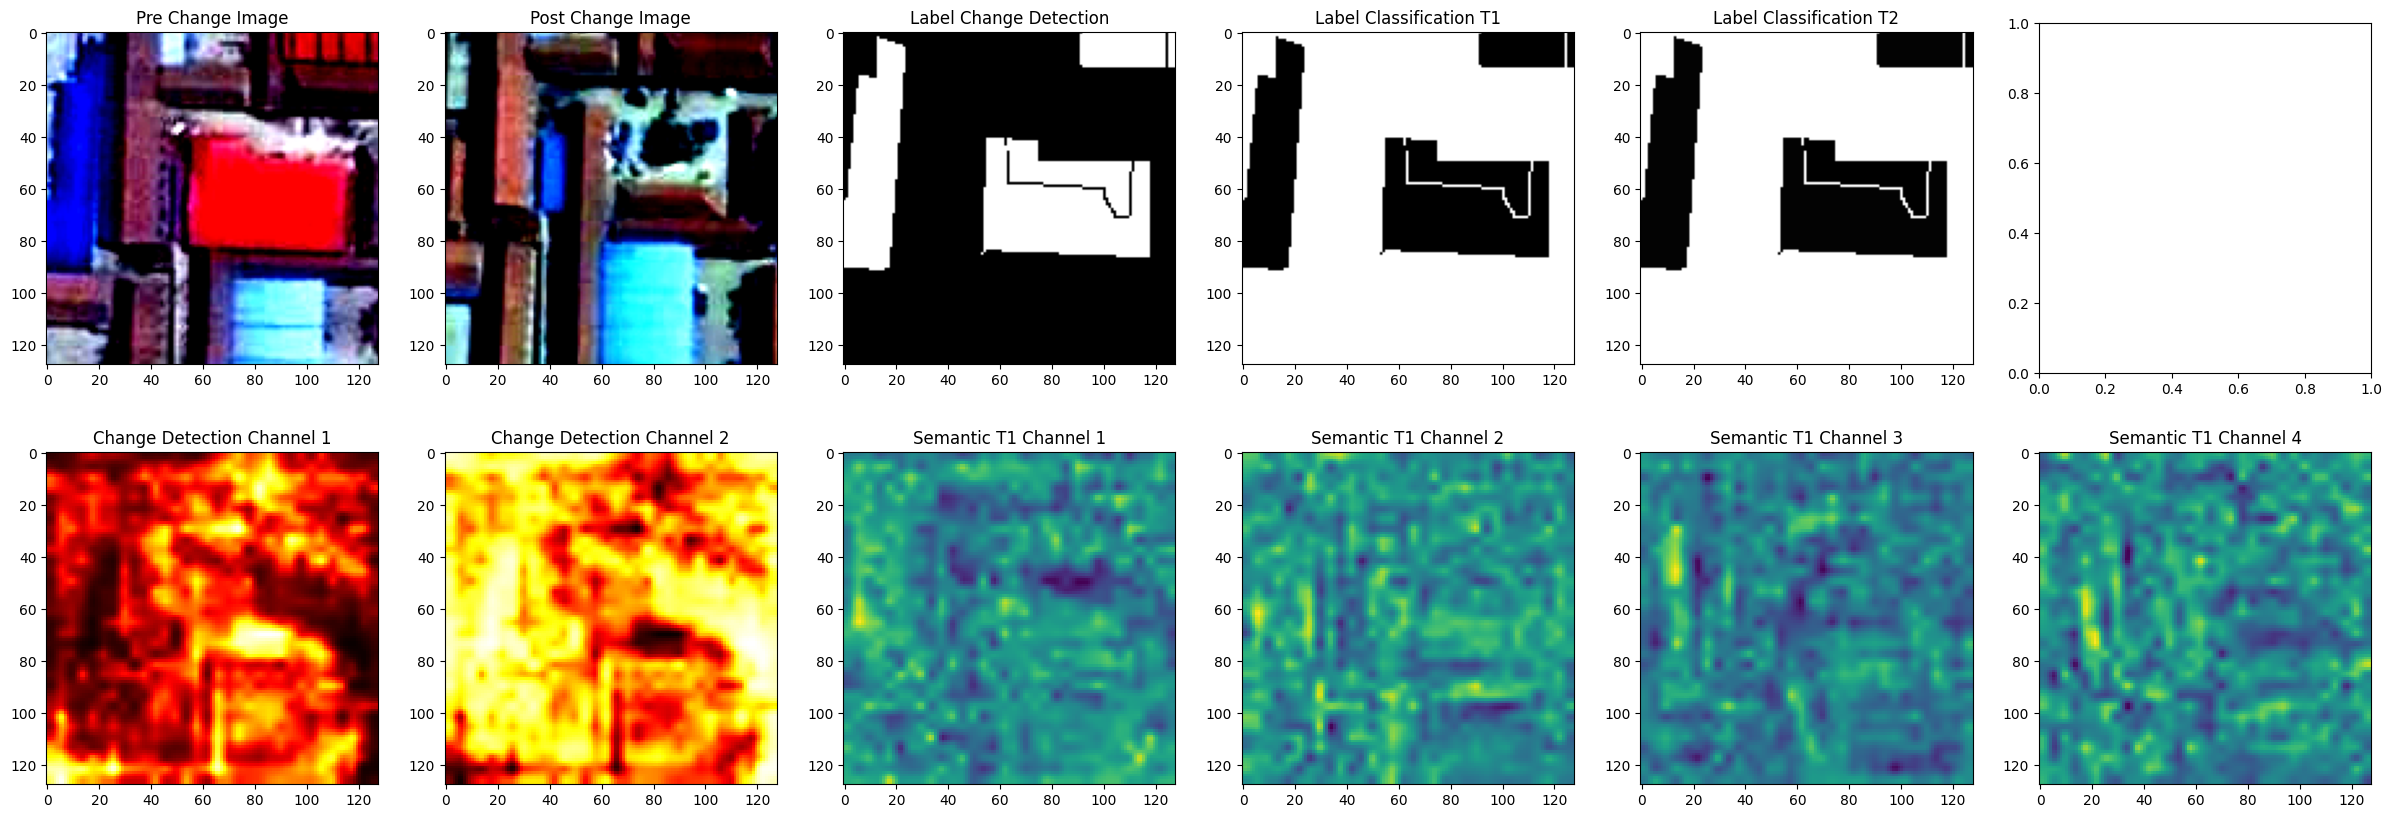

In [31]:
mod = Trainer(args)
mod.training()